              precision    recall  f1-score   support

   butterfly       0.98      0.96      0.97      2112
         cat       0.98      0.95      0.96      1668
     chicken       0.98      0.97      0.97      3098
         cow       0.94      0.83      0.89      1866
         dog       0.96      0.96      0.96      4863
    elephant       0.99      0.96      0.97      1446
       horse       0.91      0.95      0.93      2623
       sheep       0.88      0.94      0.91      1820
      spider       0.97      0.99      0.98      4821
    squirrel       0.96      0.96      0.96      1862

    accuracy                           0.96     26179
   macro avg       0.95      0.95      0.95     26179
weighted avg       0.96      0.96      0.96     26179



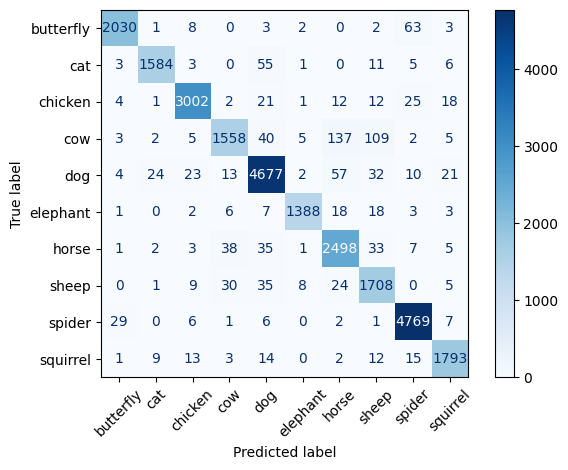

In [1]:
import torch
import torchvision.models as models
import torch.nn as nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

classes = ['butterfly', 'cat', 'chicken', 'cow', 'dog',
           'elephant', 'horse', 'sheep', 'spider', 'squirrel']

# Ladda modell
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, 10)
model.load_state_dict(torch.load('../models/resnet18_animals.pth', map_location=device))
model.to(device)
model.eval()

# Ladda testdata
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_dataset = datasets.ImageFolder('../data/raw', transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32)

# Kör evaluation
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        predicted = outputs.argmax(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Resultat
print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.tight_layout()
plt.show()